In [1]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import os
import glob

from config import config
from utils import (
    preprocess_img,
    is_valid_image,
    build_nan_pixel_mask,
    build_pixel_outlier_mask,
)


Showing 5 random samples this run.

================ Ismailia_g02 ================

Image quality:
NaN pixels: 0 / 104,748 (0.00%)
Dark pixels: 1,657 (1.58%)
Bright/saturated pixels: 0 (0.00%)
Outlier pixels detected: 0 (0.00%)
Pixels excluded by preprocessing: 1,657 (1.58%)
Processed mask changed pixels: 0
Brightness (12-band mean):
Mean/p05/p50/p95: 0.1402 / 0.0324 / 0.0511 / 0.3362
Mask distribution (raw):
Raw 1: 11,910
Raw 2: 10,951
Raw 3: 58,319
Raw 4: 23,568
Mask distribution (processed):
Greenery (1): 11,910
Sand (2): 10,951
Water (3): 58,319
Cement (4): 23,568


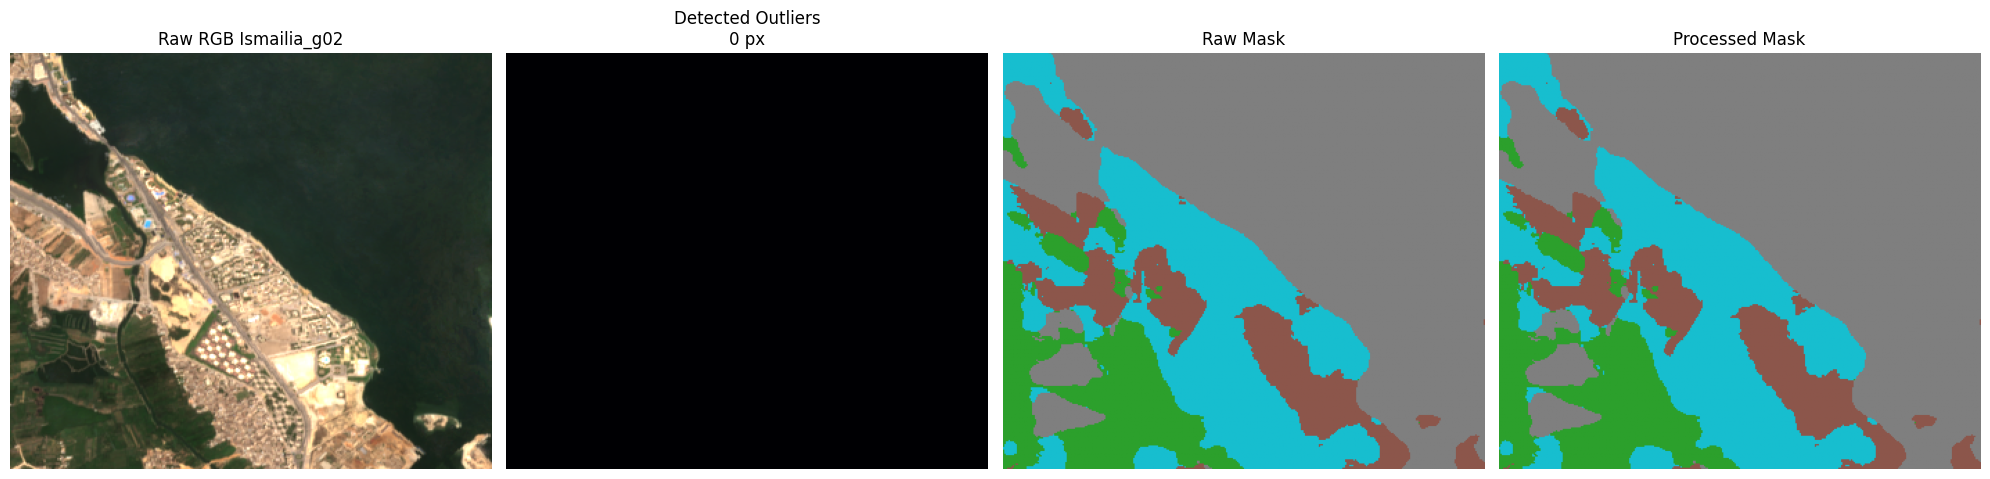


================ MarsaMatruh_g12 ================

Image quality:
NaN pixels: 0 / 105,651 (0.00%)
Dark pixels: 0 (0.00%)
Bright/saturated pixels: 0 (0.00%)
Outlier pixels detected: 14 (0.01%)
Pixels excluded by preprocessing: 14 (0.01%)
Processed mask changed pixels: 31
Brightness (12-band mean):
Mean/p05/p50/p95: 0.3384 / 0.2374 / 0.3364 / 0.4447
Mask distribution (raw):
Raw 0: 39
Raw 2: 67,193
Raw 3: 1,403
Raw 4: 37,016
Mask distribution (processed):
Unknown (0): 8
Sand (2): 67,193
Water (3): 1,434
Cement (4): 37,016


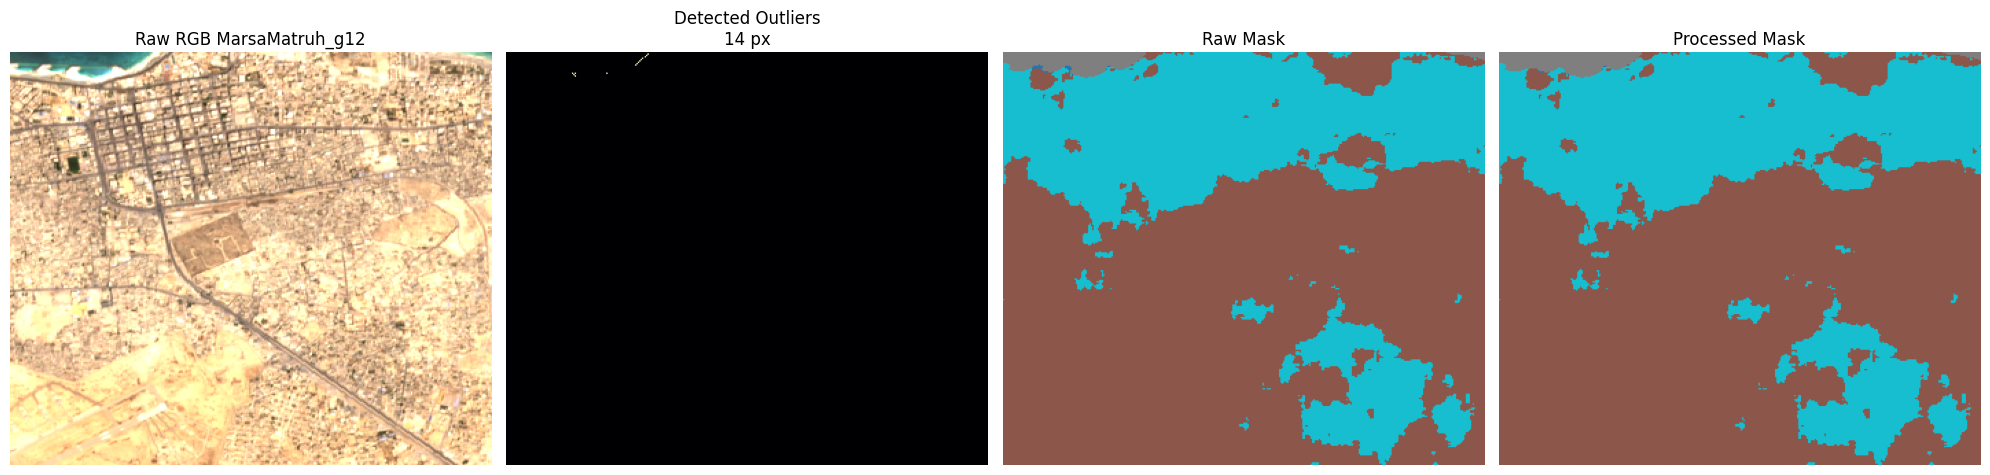


================ Minya_g20 ================

Image quality:
NaN pixels: 340 / 102,680 (0.33%)
Dark pixels: 340 (0.33%)
Bright/saturated pixels: 0 (0.00%)
Outlier pixels detected: 0 (0.00%)
Pixels excluded by preprocessing: 340 (0.33%)
Processed mask changed pixels: 0
Brightness (12-band mean):
Mean/p05/p50/p95: 0.2267 / 0.1884 / 0.2178 / 0.3088
Mask distribution (raw):
Raw 0: 340
Raw 1: 84,610
Raw 2: 10,018
Raw 3: 11
Raw 4: 7,701
Mask distribution (processed):
Unknown (0): 340
Greenery (1): 84,610
Sand (2): 10,018
Water (3): 11
Cement (4): 7,701


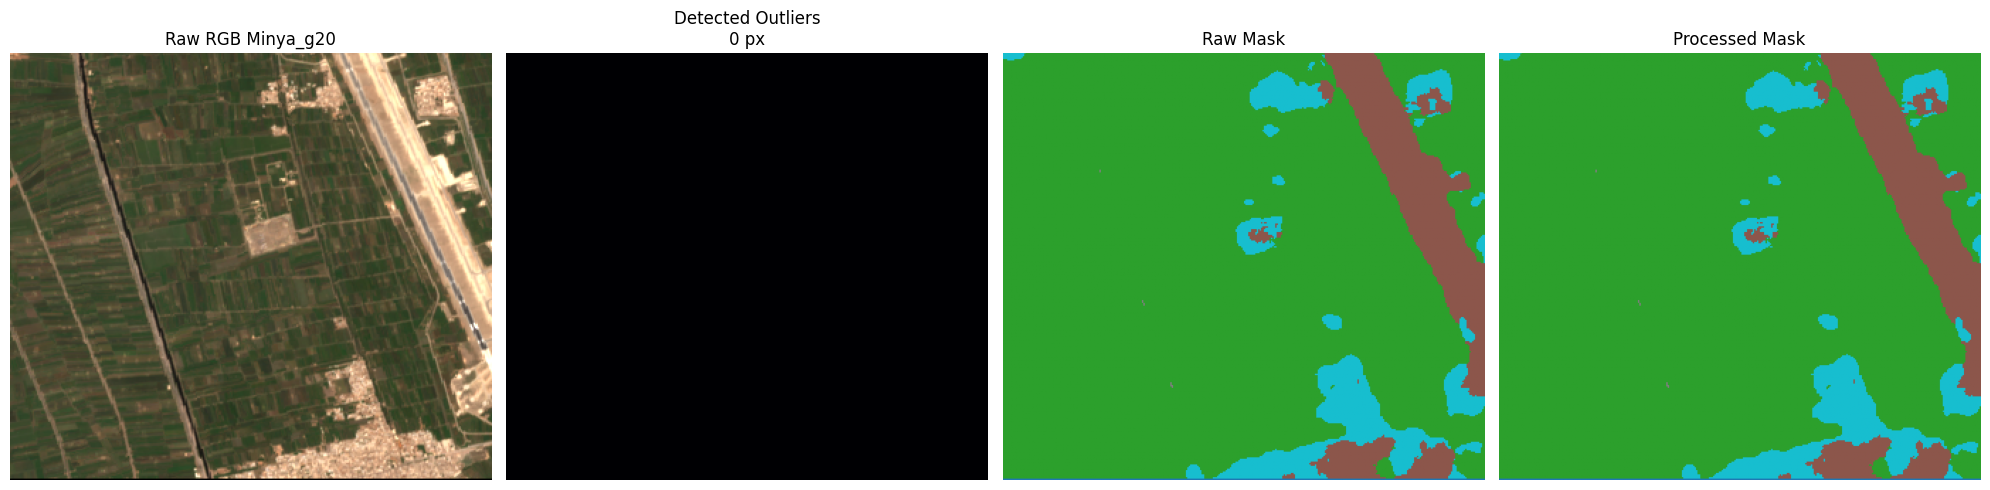


================ Suez_g12 ================

Image quality:
NaN pixels: 0 / 104,190 (0.00%)
Dark pixels: 0 (0.00%)
Bright/saturated pixels: 0 (0.00%)
Outlier pixels detected: 0 (0.00%)
Pixels excluded by preprocessing: 0 (0.00%)
Processed mask changed pixels: 0
Brightness (12-band mean):
Mean/p05/p50/p95: 0.2196 / 0.0931 / 0.2428 / 0.3672
Mask distribution (raw):
Raw 1: 1,606
Raw 2: 36,249
Raw 3: 40,402
Raw 4: 25,933
Mask distribution (processed):
Greenery (1): 1,606
Sand (2): 36,249
Water (3): 40,402
Cement (4): 25,933


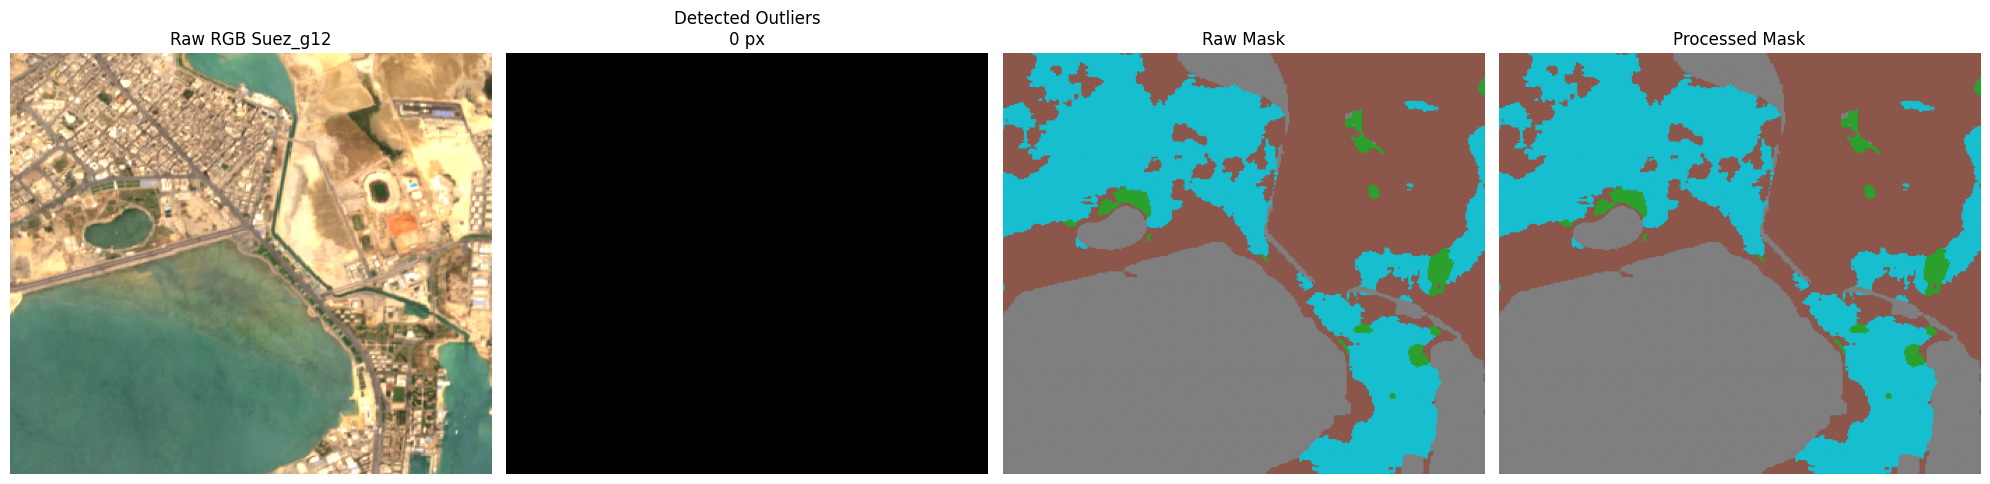


================ PortSaid_g01 ================

Image quality:
NaN pixels: 0 / 105,350 (0.00%)
Dark pixels: 0 (0.00%)
Bright/saturated pixels: 0 (0.00%)
Outlier pixels detected: 3 (0.00%)
Pixels excluded by preprocessing: 3 (0.00%)
Processed mask changed pixels: 0
Brightness (12-band mean):
Mean/p05/p50/p95: 0.2414 / 0.0811 / 0.2460 / 0.3413
Mask distribution (raw):
Raw 1: 479
Raw 2: 26,921
Raw 3: 9,078
Raw 4: 68,872
Mask distribution (processed):
Greenery (1): 479
Sand (2): 26,921
Water (3): 9,078
Cement (4): 68,872


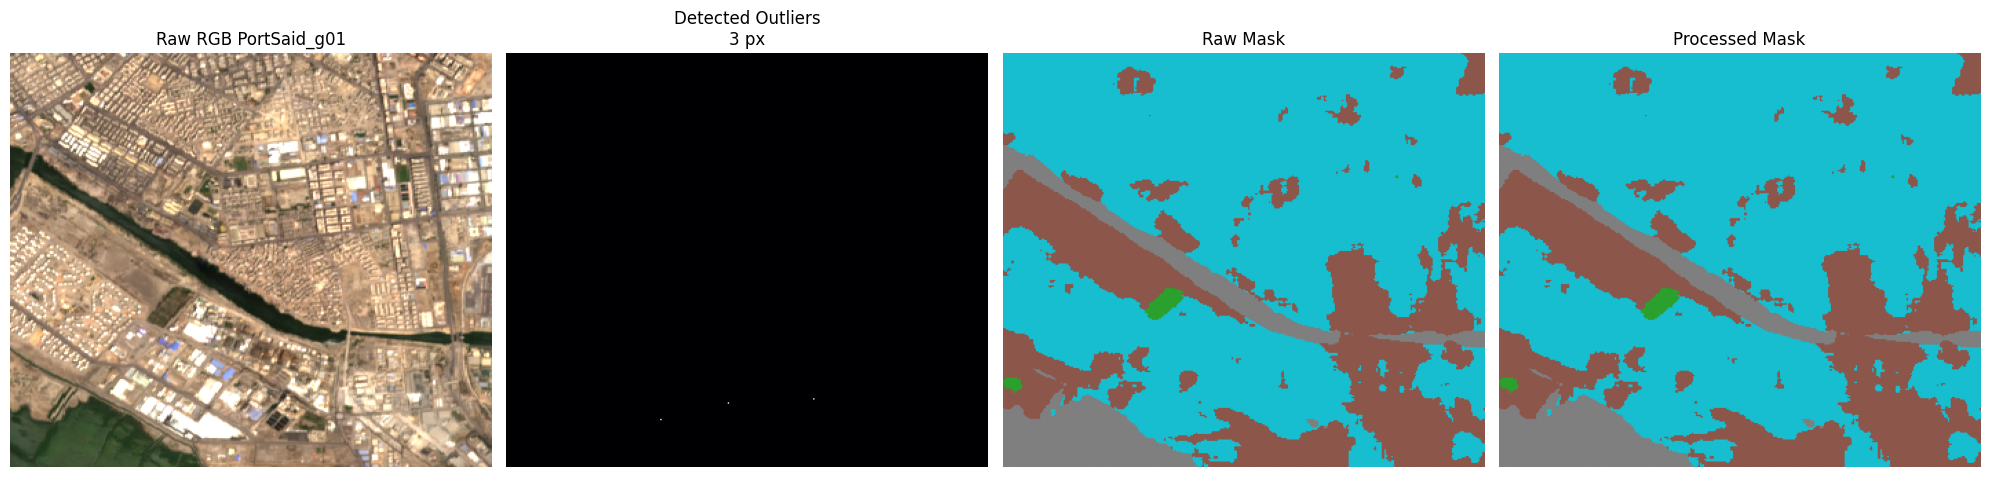

In [3]:
IMG_DIR = "./data/samples/imgs"
MASK_DIR = "./data/samples/masks"

img_paths = sorted(set(glob.glob(os.path.join(IMG_DIR, "*_Spectral_300px.tif")) + glob.glob(os.path.join(IMG_DIR, "*_Spectral.tif"))))
num_samples = min(5, len(img_paths))
selected_img_paths = np.random.default_rng().choice(img_paths, size=num_samples, replace=False)
print(f"Showing {num_samples} random samples this run.")

for img_path in selected_img_paths:
    sample_name = os.path.basename(img_path).replace("_Spectral_300px.tif", "").replace("_Spectral.tif", "")
    mask_path = os.path.join(MASK_DIR, f"{sample_name}_Mask_300px.tif")
    if not os.path.exists(mask_path):
        mask_path = os.path.join(MASK_DIR, f"{sample_name}_Mask.tif")

    if not os.path.exists(mask_path):
        print(f"Missing mask for {img_path}, skipping...")
        continue

    if not is_valid_image(img_path):
        print(f"Skipping high-NaN image (>=95% NaN pixels): {img_path}")
        continue

    print(f"\n================ {sample_name} ================\n")

    # -------- Load raw image + mask --------
    with rasterio.open(img_path) as src:
        raw_img = src.read().astype(np.float32)
    with rasterio.open(mask_path) as src:
        raw_mask = src.read(1)

    h = min(raw_img.shape[1], raw_mask.shape[0])
    w = min(raw_img.shape[2], raw_mask.shape[1])
    raw_img = raw_img[:, :h, :w]
    raw_mask = raw_mask[:h, :w]

    nan_pixels = build_nan_pixel_mask(raw_img)
    raw_img_scaled = np.clip(np.nan_to_num(raw_img, nan=0.0), 0, 10000) / 10000.0
    bands = raw_img_scaled[:12]
    band_mean = np.mean(bands, axis=0)
    band_max = np.max(bands, axis=0)
    saturated_band_count = np.sum(bands >= config.SATURATED_BAND_THRESHOLD, axis=0)
    dark_pixels = (
        (band_mean <= config.DARK_PIXEL_MEAN_THRESHOLD)
        & (band_max <= config.DARK_PIXEL_MAX_THRESHOLD)
    )
    bright_pixels = (
        (band_mean >= config.BRIGHT_PIXEL_MEAN_THRESHOLD)
        | (saturated_band_count >= config.MAX_SATURATED_BANDS)
    )
    outlier_pixels = build_pixel_outlier_mask(bands)

    # -------- Shared preprocessing path --------
    img, processed_mask, pixel_valid = preprocess_img(img_path, mask_path, train=False)

    # -------- RGB for display --------
    rgb_raw = np.transpose(raw_img_scaled[[3, 2, 1]], (1, 2, 0))
    rgb_raw = np.clip(rgb_raw * 3.0, 0, 1)

    # -------- Stats --------
    raw_values, raw_counts = np.unique(raw_mask, return_counts=True)
    processed_values, processed_counts = np.unique(processed_mask, return_counts=True)
    brightness_valid = ~nan_pixels
    raw_brightness = band_mean[brightness_valid]

    print("Image quality:")
    print(f"NaN pixels: {int(nan_pixels.sum()):,} / {nan_pixels.size:,} ({100 * nan_pixels.mean():.2f}%)")
    print(f"Dark pixels: {int(dark_pixels.sum()):,} ({100 * dark_pixels.mean():.2f}%)")
    print(f"Bright/saturated pixels: {int(bright_pixels.sum()):,} ({100 * bright_pixels.mean():.2f}%)")
    print(f"Outlier pixels detected: {int(outlier_pixels.sum()):,} ({100 * outlier_pixels.mean():.2f}%)")
    print(f"Pixels excluded by preprocessing: {int((~pixel_valid).sum()):,} ({100 * (~pixel_valid).mean():.2f}%)")
    print(f"Processed mask changed pixels: {int((raw_mask != processed_mask).sum()):,}")

    if raw_brightness.size > 0:
        print("Brightness (12-band mean):")
        print(
            f"Mean/p05/p50/p95: {raw_brightness.mean():.4f} / "
            f"{np.percentile(raw_brightness, 5):.4f} / {np.percentile(raw_brightness, 50):.4f} / {np.percentile(raw_brightness, 95):.4f}"
        )

    print("Mask distribution (raw):")
    for value, count in zip(raw_values, raw_counts):
        print(f"Raw {int(value)}: {count:,}")

    print("Mask distribution (processed):")
    for value, count in zip(processed_values, processed_counts):
        class_name = config.CLASS_NAMES.get(int(value), "Unknown")
        print(f"{class_name} ({int(value)}): {count:,}")

    # -------- Visualization --------
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].set_title(f"Raw RGB {sample_name}")
    axes[0].imshow(rgb_raw)
    axes[0].axis("off")

    axes[1].set_title(f"Detected Outliers\n{int(outlier_pixels.sum()):,} px")
    axes[1].imshow(outlier_pixels, cmap="magma")
    axes[1].axis("off")

    axes[2].set_title("Raw Mask")
    axes[2].imshow(raw_mask, cmap="tab10", vmin=0, vmax=4)
    axes[2].axis("off")

    axes[3].set_title("Processed Mask")
    axes[3].imshow(processed_mask, cmap="tab10", vmin=0, vmax=4)
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()
